In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [50]:
df = pd.read_csv("synthetic_dataset_10000x20.csv")
print("Shape:", df.shape)
df.head()

Shape: (10000, 21)


,customer_id,age,income,savings,monthly_expenses,num_dependents,credit_score,loan_amount,loan_term_months,employment_years,...,education,marital_status,region,recent_default,has_credit_card,signup_date,signup_dayofweek,debt_to_income,sin_age,target_default_risk
0,CUST006253,30,66737.0,11155.0,2272.0,2,605.076204,26965.0,48,3.9,...,HS,Single,West,1,1,2020-07-05,6,0.404,0.141120,1
1,CUST004685,22,70740.0,997.0,1934.0,1,683.291967,4681.0,36,0.7,...,Bachelors,Married,East,0,0,2018-10-03,2,0.066,0.808496,1
2,CUST001732,68,38890.0,1929.0,1696.0,0,658.003360,12633.0,72,2.2,...,Bachelors,Single,East,0,1,2018-05-30,2,0.325,0.494113,0
3,CUST004743,49,29049.0,6284.0,2485.0,1,707.477864,20881.0,36,2.7,...,HS,Married,South,0,1,2018-04-22,6,0.719,-0.982453,0
4,CUST004522,74,60063.0,924.0,3179.0,2,564.768511,19438.0,36,10.3,...,Masters,Single,West,0,0,2019-12-03,1,0.324,0.898708,1


In [51]:
df.head()

,customer_id,age,income,savings,monthly_expenses,num_dependents,credit_score,loan_amount,loan_term_months,employment_years,...,education,marital_status,region,recent_default,has_credit_card,signup_date,signup_dayofweek,debt_to_income,sin_age,target_default_risk
0,CUST006253,30,66737.0,11155.0,2272.0,2,605.076204,26965.0,48,3.9,...,HS,Single,West,1,1,2020-07-05,6,0.404,0.141120,1
1,CUST004685,22,70740.0,997.0,1934.0,1,683.291967,4681.0,36,0.7,...,Bachelors,Married,East,0,0,2018-10-03,2,0.066,0.808496,1
2,CUST001732,68,38890.0,1929.0,1696.0,0,658.003360,12633.0,72,2.2,...,Bachelors,Single,East,0,1,2018-05-30,2,0.325,0.494113,0
3,CUST004743,49,29049.0,6284.0,2485.0,1,707.477864,20881.0,36,2.7,...,HS,Married,South,0,1,2018-04-22,6,0.719,-0.982453,0
4,CUST004522,74,60063.0,924.0,3179.0,2,564.768511,19438.0,36,10.3,...,Masters,Single,West,0,0,2019-12-03,1,0.324,0.898708,1


STEP 1 -EDA

In [52]:
df.shape

(10000, 21)

In [53]:
df.columns

Index(['customer_id', 'age', 'income', 'savings', 'monthly_expenses',
       'num_dependents', 'credit_score', 'loan_amount', 'loan_term_months',
       'employment_years', 'home_ownership', 'education', 'marital_status',
       'region', 'recent_default', 'has_credit_card', 'signup_date',
       'signup_dayofweek', 'debt_to_income', 'sin_age', 'target_default_risk'],
      dtype='object')

In [54]:
df.head(10)

,customer_id,age,income,savings,monthly_expenses,num_dependents,credit_score,loan_amount,loan_term_months,employment_years,...,education,marital_status,region,recent_default,has_credit_card,signup_date,signup_dayofweek,debt_to_income,sin_age,target_default_risk
0,CUST006253,30,66737.0,11155.0,2272.0,2,605.076204,26965.0,48,3.9,...,HS,Single,West,1,1,2020-07-05,6,0.404,0.141120,1
1,CUST004685,22,70740.0,997.0,1934.0,1,683.291967,4681.0,36,0.7,...,Bachelors,Married,East,0,0,2018-10-03,2,0.066,0.808496,1
2,CUST001732,68,38890.0,1929.0,1696.0,0,658.003360,12633.0,72,2.2,...,Bachelors,Single,East,0,1,2018-05-30,2,0.325,0.494113,0
3,CUST004743,49,29049.0,6284.0,2485.0,1,707.477864,20881.0,36,2.7,...,HS,Married,South,0,1,2018-04-22,6,0.719,-0.982453,0
4,CUST004522,74,60063.0,924.0,3179.0,2,564.768511,19438.0,36,10.3,...,Masters,Single,West,0,0,2019-12-03,1,0.324,0.898708,1
5,CUST006341,56,37852.0,4826.0,3055.0,3,686.863529,15328.0,48,1.3,...,Masters,Single,South,0,1,2018-11-08,3,0.405,-0.631267,0
6,CUST000577,19,64635.0,5240.0,2737.0,2,564.799942,23469.0,48,6.7,...,HS,Divorced,North,0,1,2021-12-14,1,0.363,0.946300,1
7,CUST005203,44,58003.0,6113.0,1607.0,1,590.309854,1000.0,48,0.5,...,Other,Single,East,0,0,2019-10-02,2,0.017,-0.951602,1
8,CUST006364,18,41132.0,14936.0,1414.0,2,616.701030,22800.0,72,2.1,...,PhD,Married,East,0,1,2018-04-18,2,0.554,0.973848,0
9,CUST000440,29,51038.0,12639.0,2514.0,1,604.902807,6050.0,60,6.0,...,Masters,Single,East,0,0,2022-02-05,5,0.119,0.239249,0


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          10000 non-null  object 
 1   age                  10000 non-null  int64  
 2   income               9682 non-null   float64
 3   savings              9689 non-null   float64
 4   monthly_expenses     9675 non-null   float64
 5   num_dependents       10000 non-null  int64  
 6   credit_score         9674 non-null   float64
 7   loan_amount          10000 non-null  float64
 8   loan_term_months     10000 non-null  int64  
 9   employment_years     10000 non-null  float64
 10  home_ownership       10000 non-null  object 
 11  education            10000 non-null  object 
 12  marital_status       10000 non-null  object 
 13  region               10000 non-null  object 
 14  recent_default       10000 non-null  int64  
 15  has_credit_card      10000 non-null  

In [56]:
df.columns

Index(['customer_id', 'age', 'income', 'savings', 'monthly_expenses',
       'num_dependents', 'credit_score', 'loan_amount', 'loan_term_months',
       'employment_years', 'home_ownership', 'education', 'marital_status',
       'region', 'recent_default', 'has_credit_card', 'signup_date',
       'signup_dayofweek', 'debt_to_income', 'sin_age', 'target_default_risk'],
      dtype='object')

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          10000 non-null  object 
 1   age                  10000 non-null  int64  
 2   income               9682 non-null   float64
 3   savings              9689 non-null   float64
 4   monthly_expenses     9675 non-null   float64
 5   num_dependents       10000 non-null  int64  
 6   credit_score         9674 non-null   float64
 7   loan_amount          10000 non-null  float64
 8   loan_term_months     10000 non-null  int64  
 9   employment_years     10000 non-null  float64
 10  home_ownership       10000 non-null  object 
 11  education            10000 non-null  object 
 12  marital_status       10000 non-null  object 
 13  region               10000 non-null  object 
 14  recent_default       10000 non-null  int64  
 15  has_credit_card      10000 non-null  

In [58]:
df.isnull().sum()

customer_id              0
age                      0
income                 318
savings                311
monthly_expenses       325
num_dependents           0
credit_score           326
loan_amount              0
loan_term_months         0
employment_years         0
home_ownership           0
education                0
marital_status           0
region                   0
recent_default           0
has_credit_card          0
signup_date              0
signup_dayofweek         0
debt_to_income           0
sin_age                  0
target_default_risk      0
dtype: int64

In [59]:
# Unique values in categorical columns
for col in ['education', 'marital_status', 'region', 'home_ownership']:
    print(col, ":", df[col].unique())

education : ['HS' 'Bachelors' 'Masters' 'Other' 'PhD' 'Bachlors']
marital_status : ['Single' 'Married' 'Divorced' 'Widowed']
region : ['West' 'East' 'South' 'North']
home_ownership : ['RENT' 'OWN' 'MORTGAGE' 'OTHER']


In [60]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage.sort_values(ascending=False)

credit_score           3.26
monthly_expenses       3.25
income                 3.18
savings                3.11
customer_id            0.00
region                 0.00
sin_age                0.00
debt_to_income         0.00
signup_dayofweek       0.00
signup_date            0.00
has_credit_card        0.00
recent_default         0.00
home_ownership         0.00
marital_status         0.00
education              0.00
age                    0.00
employment_years       0.00
loan_term_months       0.00
loan_amount            0.00
num_dependents         0.00
target_default_risk    0.00
dtype: float64

In [61]:
for column in df.columns:
    print("\n", column)
    print(df[column].unique()[:20])


 customer_id
['CUST006253' 'CUST004685' 'CUST001732' 'CUST004743' 'CUST004522'
 'CUST006341' 'CUST000577' 'CUST005203' 'CUST006364' 'CUST000440'
 'CUST002751' 'CUST007488' 'CUST005273' 'CUST005654' 'CUST004000'
 'CUST006034' 'CUST000583' 'CUST009931' 'CUST007052' 'CUST008159']

 age
[30 22 68 49 74 56 19 44 18 29 53 40 41 42 58 66 72 69 27 47]

 income
[ 66737.  70740.  38890.  29049.  60063.  37852.  64635.  58003.  41132.
  51038.  23159. 163249.  28500.     nan  33641. 120498.  37130. 135563.
 178808.  26878.]

 savings
[11155.   997.  1929.  6284.   924.  4826.  5240.  6113. 14936. 12639.
  4693.  4837. 21193.  4289.  3398.  1183.  1123.  2010.    nan  4896.]

 monthly_expenses
[2272. 1934. 1696. 2485. 3179. 3055. 2737. 1607. 1414. 2514. 2237. 2040.
 1462. 2140.  200.   nan 2145. 1734. 2976. 1631.]

 num_dependents
[2 1 0 3 4 5 6 7]

 credit_score
[605.07620415 683.2919671  658.00335996 707.47786357 564.76851072
 686.86352919 564.79994161 590.30985376 616.70102956 604.90280667
 46

In [62]:
categorical_columns = df.select_dtypes(include="object").columns

categorical_columns

Index(['customer_id', 'home_ownership', 'education', 'marital_status',
       'region', 'signup_date'],
      dtype='object')

In [63]:
for column in categorical_columns:
    print("\n==============================")
    print(column)
    print("==============================")
    print(df[column].value_counts(dropna=False))


customer_id
customer_id
CUST006253    1
CUST001238    1
CUST001308    1
CUST009430    1
CUST000999    1
             ..
CUST002729    1
CUST009598    1
CUST004986    1
CUST006847    1
CUST007271    1
Name: count, Length: 10000, dtype: int64

home_ownership
home_ownership
RENT        4524
OWN         2526
MORTGAGE    2498
OTHER        452
Name: count, dtype: int64

education
education
Bachelors    4443
HS           2546
Masters      1962
Other         500
PhD           462
Bachlors       87
Name: count, dtype: int64

marital_status
marital_status
Single      4486
Married     4002
Divorced    1000
Widowed      512
Name: count, dtype: int64

region
region
East     2553
South    2523
North    2479
West     2445
Name: count, dtype: int64

signup_date
signup_date
2018-06-22    14
2021-04-14    13
2021-01-27    13
2021-11-14    13
2022-05-07    12
              ..
2023-04-16     1
2022-05-31     1
2020-03-22     1
2022-07-31     1
2018-11-04     1
Name: count, Length: 1982, dtype: int64


target_default_risk
1    5132
0    4868
Name: count, dtype: int64


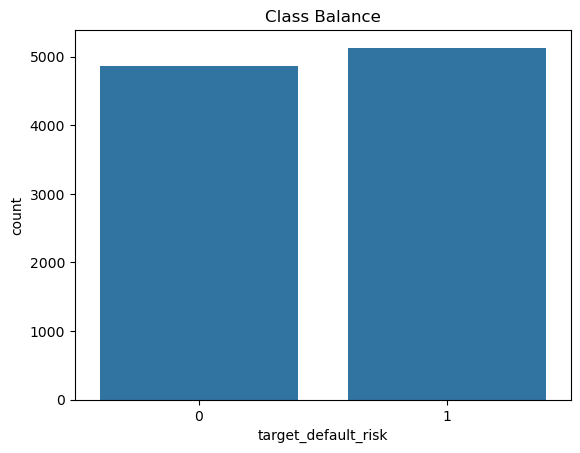

In [64]:
# Target class 
print(df['target_default_risk'].value_counts())
sns.countplot(x='target_default_risk', data=df)
plt.title("Class Balance")
plt.show()

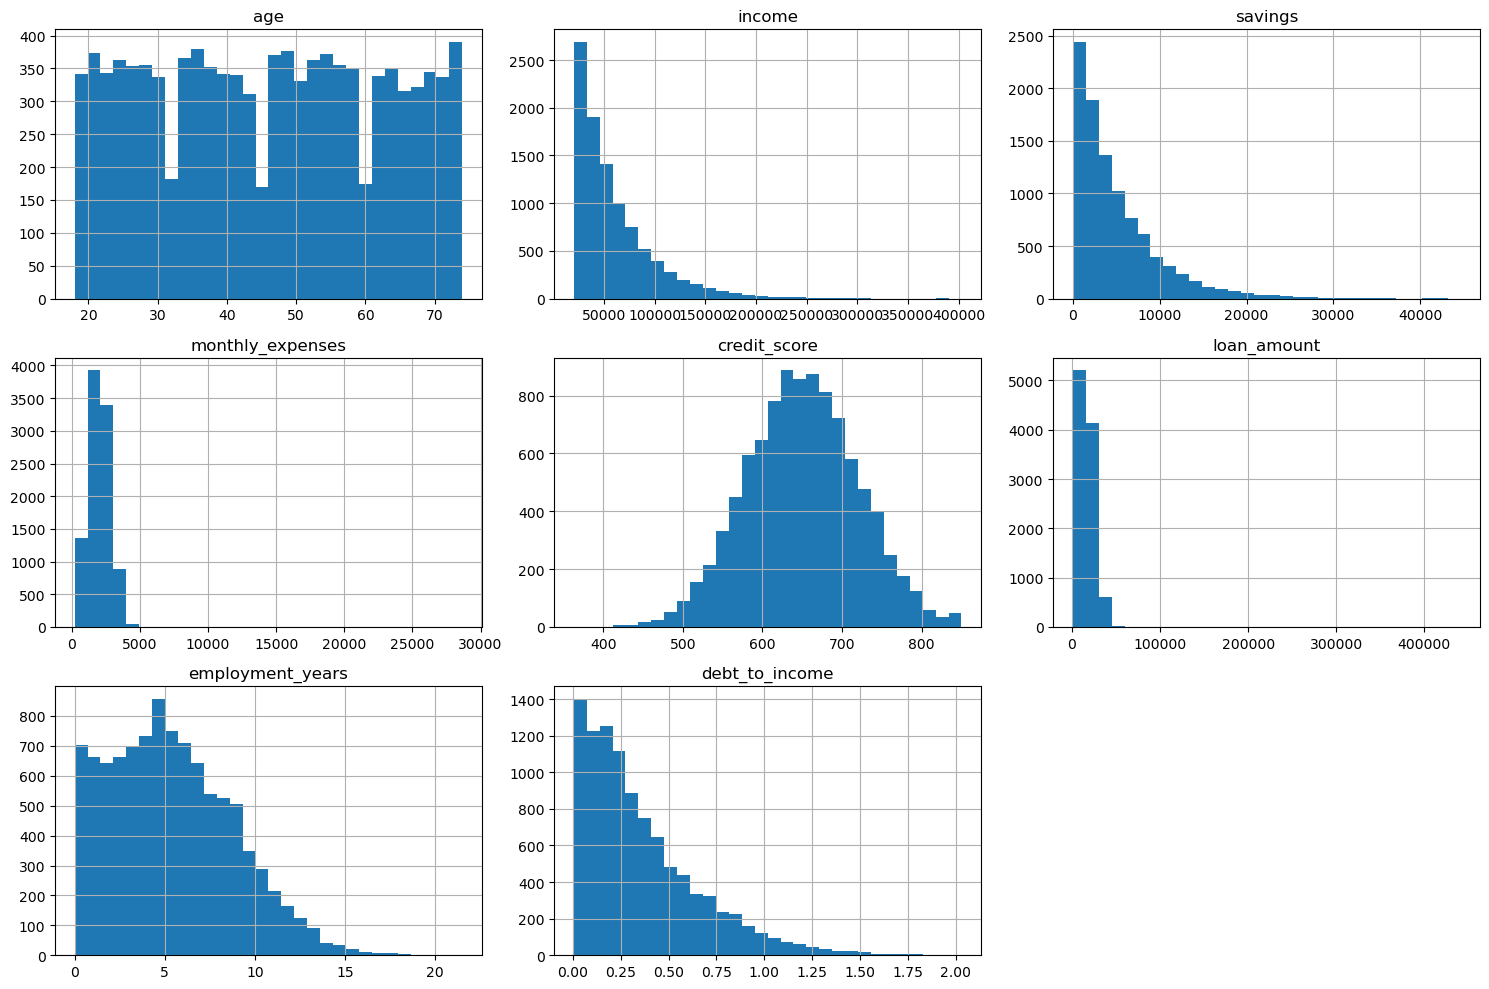

In [65]:
# Numeric distributions
numeric_cols = ['age', 'income', 'savings', 'monthly_expenses', 'credit_score',
                 'loan_amount', 'employment_years', 'debt_to_income']

df[numeric_cols].hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

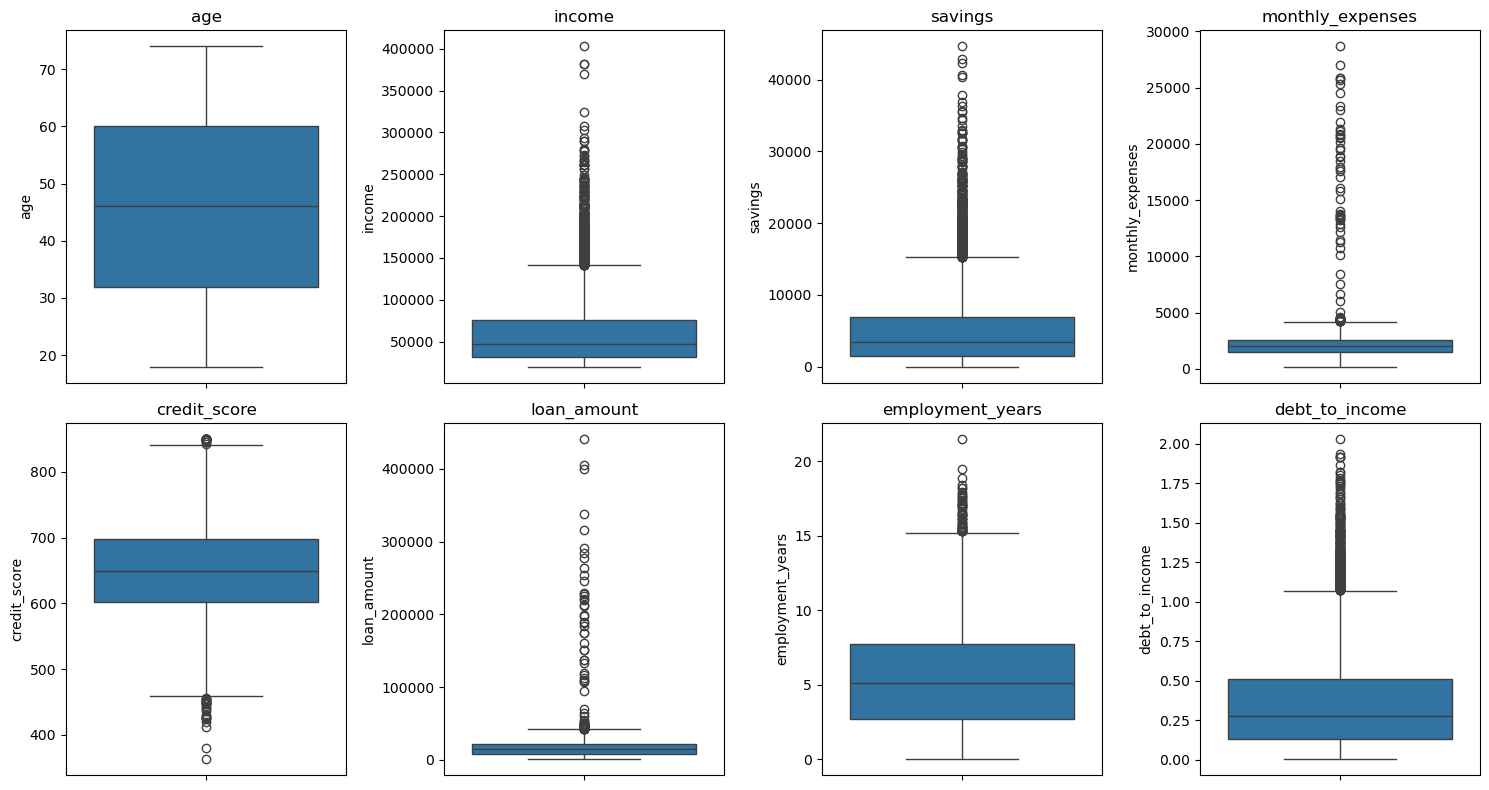

In [66]:
# Outlier detection (boxplots)
plt.figure(figsize=(15, 8))
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 4, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

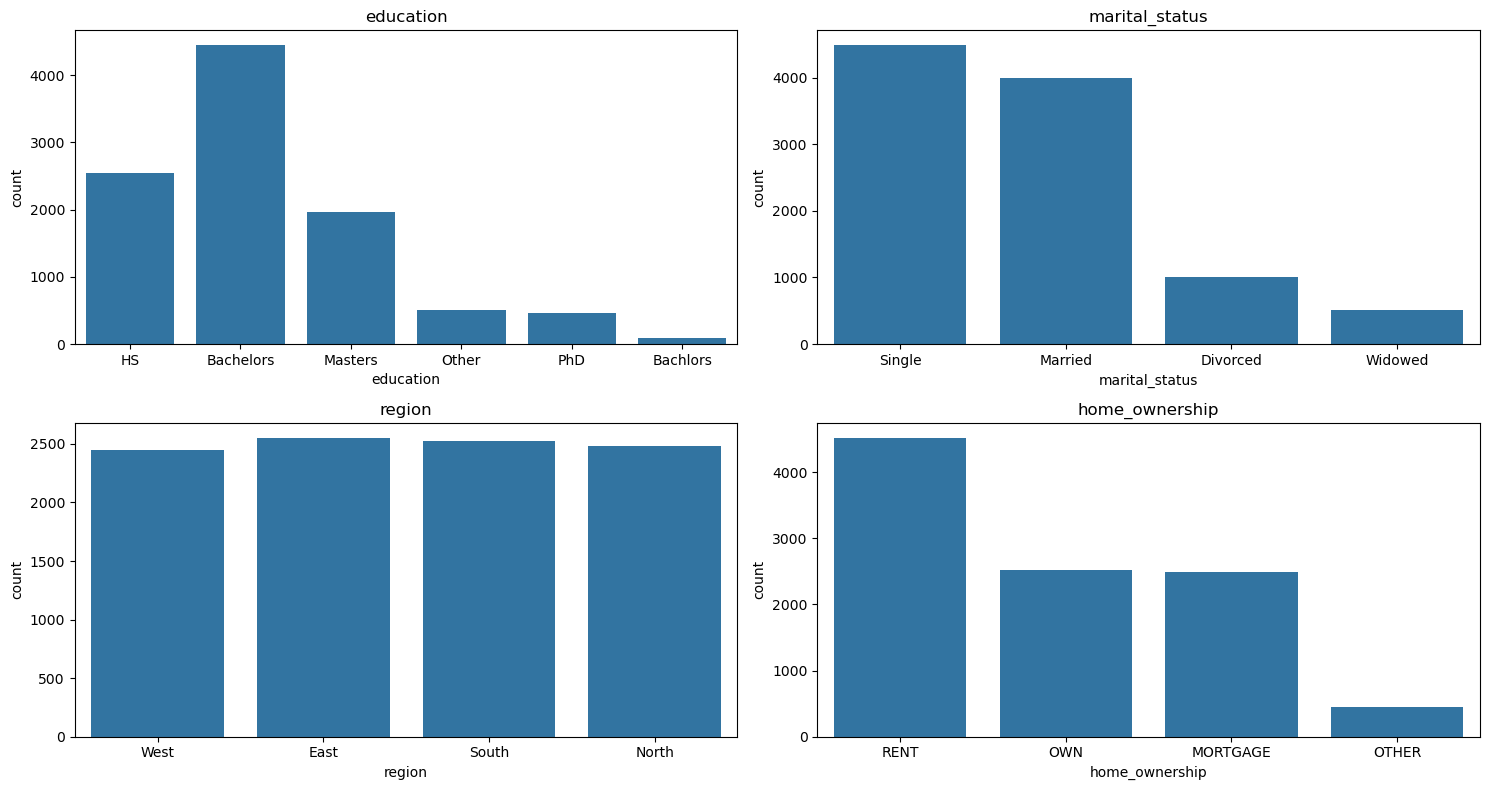

In [67]:
# Categorical variable counts
cat_cols = ['education', 'marital_status', 'region', 'home_ownership']
plt.figure(figsize=(15, 8))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 2, i+1)
    sns.countplot(x=col, data=df)
    plt.title(col)
plt.tight_layout()
plt.show()

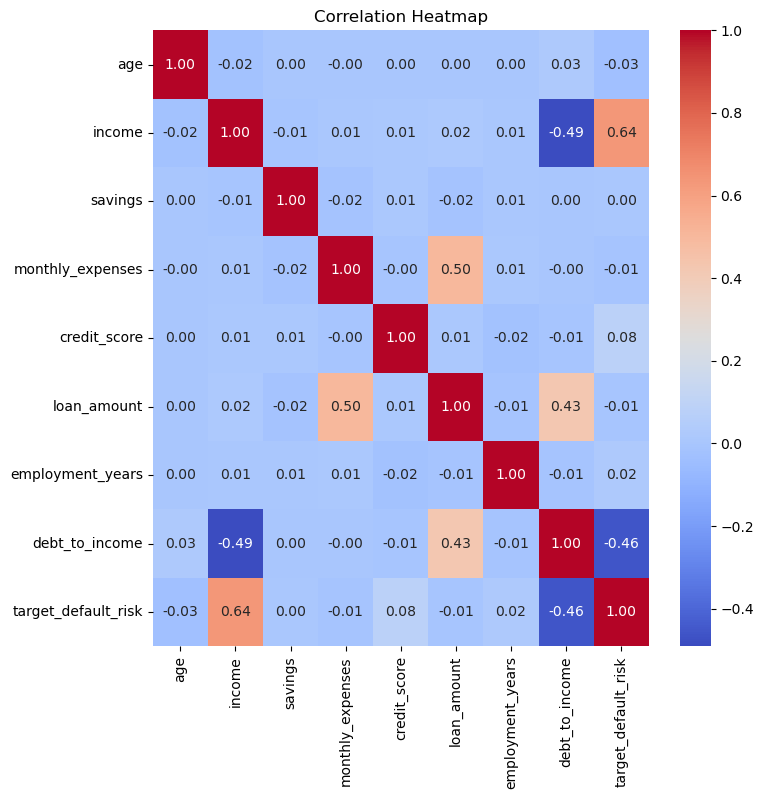

In [68]:
# heatmap
plt.figure(figsize=(8, 8))
sns.heatmap(df[numeric_cols + ['target_default_risk']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

STEP 2 Feature Engineering

In [69]:
# Fix typo in education
df['education'] = df['education'].replace({'Bachlors': 'Bachelors'})
print(df['education'].unique())

['HS' 'Bachelors' 'Masters' 'Other' 'PhD']


In [70]:
# Handle missing values 
missing_cols = ['income', 'savings', 'monthly_expenses', 'credit_score']
for col in missing_cols:
    df[col] = df[col].fillna(df[col].median())

print(df.isnull().sum())

customer_id            0
age                    0
income                 0
savings                0
monthly_expenses       0
num_dependents         0
credit_score           0
loan_amount            0
loan_term_months       0
employment_years       0
home_ownership         0
education              0
marital_status         0
region                 0
recent_default         0
has_credit_card        0
signup_date            0
signup_dayofweek       0
debt_to_income         0
sin_age                0
target_default_risk    0
dtype: int64


In [71]:
def cap_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series.clip(lower, upper)

for col in numeric_cols:
    df[col] = cap_outliers(df[col])

In [72]:
# New features
df['income_per_dependent'] = df['income'] / (df['num_dependents'] + 1)

df['signup_date'] = pd.to_datetime(df['signup_date'])
latest_date = df['signup_date'].max()
df['recency_days'] = (latest_date - df['signup_date']).dt.days

df.drop(columns=['signup_date', 'customer_id'], inplace=True)

In [73]:
# Encode categorical variables
df = pd.get_dummies(df, columns=['home_ownership', 'education', 'marital_status', 'region'], drop_first=True)
df.head()

,age,income,savings,monthly_expenses,num_dependents,credit_score,loan_amount,loan_term_months,employment_years,recent_default,...,education_HS,education_Masters,education_Other,education_PhD,marital_status_Married,marital_status_Single,marital_status_Widowed,region_North,region_South,region_West
0,30,66737.0,11155.0,2272.0,2,605.076204,26965.0,48,3.9,1,...,True,False,False,False,False,True,False,False,False,True
1,22,70740.0,997.0,1934.0,1,683.291967,4681.0,36,0.7,0,...,False,False,False,False,True,False,False,False,False,False
2,68,38890.0,1929.0,1696.0,0,658.003360,12633.0,72,2.2,0,...,False,False,False,False,False,True,False,False,False,False
3,49,29049.0,6284.0,2485.0,1,707.477864,20881.0,36,2.7,0,...,True,False,False,False,True,False,False,False,True,False
4,74,60063.0,924.0,3179.0,2,564.768511,19438.0,36,10.3,0,...,False,True,False,False,False,True,False,False,False,True


In [74]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['target_default_risk'])
y = df['target_default_risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

STEP 3 Model Evaluation

In [75]:
!pip install xgboost

In [76]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [77]:
import sys
!{sys.executable} -m pip install xgboost

In [78]:
def evaluate_model(name, y_test, y_pred):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"--- {name} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print()
    return acc, prec, rec, f1

metrics_dict = {}

In [79]:
# Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)
metrics_dict["Logistic Regression"] = evaluate_model("Logistic Regression", y_test, y_pred_lr)

--- Logistic Regression ---
Accuracy : 0.9395
Precision: 0.9613
Recall   : 0.9191
F1 Score : 0.9397
Confusion Matrix:
 [[936  38]
 [ 83 943]]



In [80]:
# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
metrics_dict["Decision Tree"] = evaluate_model("Decision Tree", y_test, y_pred_dt)

--- Decision Tree ---
Accuracy : 0.9280
Precision: 0.9315
Recall   : 0.9279
F1 Score : 0.9297
Confusion Matrix:
 [[904  70]
 [ 74 952]]



In [81]:
# SVM
svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)
metrics_dict["SVM"] = evaluate_model("SVM", y_test, y_pred_svm)

--- SVM ---
Accuracy : 0.9270
Precision: 0.9545
Recall   : 0.9006
F1 Score : 0.9268
Confusion Matrix:
 [[930  44]
 [102 924]]



In [82]:
# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
metrics_dict["Random Forest"] = evaluate_model("Random Forest", y_test, y_pred_rf)

--- Random Forest ---
Accuracy : 0.9430
Precision: 0.9606
Recall   : 0.9269
F1 Score : 0.9435
Confusion Matrix:
 [[935  39]
 [ 75 951]]



In [83]:
# XGBoost
xgb = XGBClassifier(eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
metrics_dict["XGBoost"] = evaluate_model("XGBoost", y_test, y_pred_xgb)

--- XGBoost ---
Accuracy : 0.9560
Precision: 0.9644
Recall   : 0.9493
F1 Score : 0.9568
Confusion Matrix:
 [[938  36]
 [ 52 974]]



In [84]:
results_df = pd.DataFrame(metrics_dict, index=["Accuracy", "Precision", "Recall", "F1-Score"]).T
results_df = results_df.sort_values(by="Accuracy", ascending=False)
print(results_df.round(4))

                     Accuracy  Precision  Recall  F1-Score
XGBoost                0.9560     0.9644  0.9493    0.9568
Random Forest          0.9430     0.9606  0.9269    0.9435
Logistic Regression    0.9395     0.9613  0.9191    0.9397
Decision Tree          0.9280     0.9315  0.9279    0.9297
SVM                    0.9270     0.9545  0.9006    0.9268


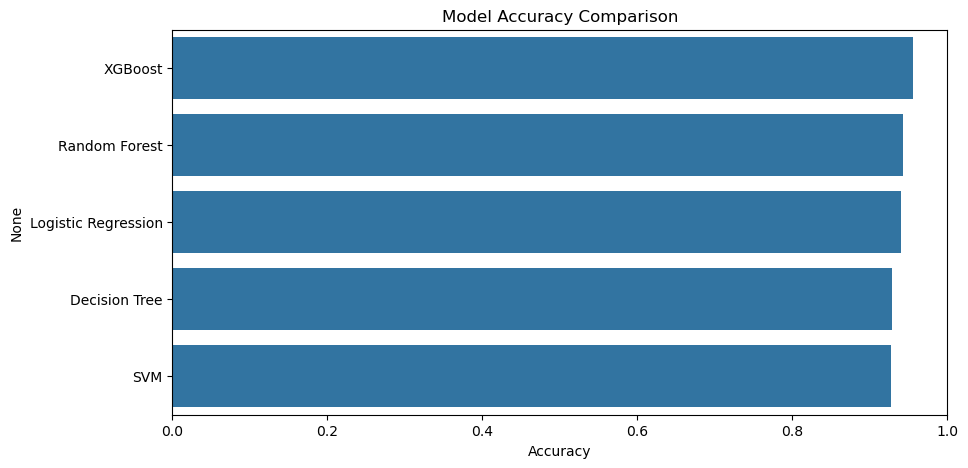

In [85]:
plt.figure(figsize=(10, 5))
sns.barplot(x=results_df["Accuracy"], y=results_df.index)
plt.title("Model Accuracy Comparison")
plt.xlim(0, 1)
plt.show()